In [1]:

import numpy as np
import pickle
from scipy.optimize import minimize_scalar
from scipy.stats import ttest_rel
import warnings
warnings.filterwarnings('ignore')

# Load omega values
with open('omega_values_N1e6.pkl', 'rb') as f:
 omega_values = pickle.load(f)

print("Loaded omega_values for N=10^6")
print(f"Shape: {omega_values.shape}")
print(f"First 10 values (Ω(1) through Ω(10)): {omega_values[:10]}")


Loaded omega_values for N=10^6
Shape: (1000000,)
First 10 values (Ω(1) through Ω(10)): [0 1 1 2 1 2 1 3 2 2]


In [2]:

# Define the primitive character chi_5 (mod 5)
# For the primitive character mod 5, we have:
# chi_5(n) depends on n mod 5:
# chi_5(0) = 0 (for n divisible by 5)
# chi_5(1) = 1
# chi_5(2) = i
# chi_5(3) = -i
# chi_5(4) = -1

def chi_5(n):
 """Primitive Dirichlet character mod 5"""
 n_mod = n % 5
 if n_mod == 0:
 return 0
 elif n_mod == 1:
 return 1
 elif n_mod == 2:
 return 1j
 elif n_mod == 3:
 return -1j
 elif n_mod == 4:
 return -1
 
def chi_5_conjugate(n):
 """Conjugate of the primitive Dirichlet character mod 5"""
 return np.conj(chi_5(n))

# Generate coefficients for F_conj = L(s, chi_5) + i*L(s, chi_5_bar)
# a_F(n) = chi_5(n) + i*chi_5_bar(n) = chi_5(n) + i*conj(chi_5(n))
N = 1000000
a_F = np.zeros(N, dtype=np.complex128)

for n in range(1, N+1):
 chi_val = chi_5(n)
 a_F[n-1] = chi_val + 1j * np.conj(chi_val)

print("Generated coefficients for F_conj")
print(f"Total coefficients: {len(a_F)}")
print(f"First 20 coefficients:")
for n in range(1, 21):
 print(f" a_F({n}) = {a_F[n-1]:.4f}")


Generated coefficients for F_conj
Total coefficients: 1000000
First 20 coefficients:
 a_F(1) = 1.0000+1.0000j
 a_F(2) = 1.0000+1.0000j
 a_F(3) = -1.0000-1.0000j
 a_F(4) = -1.0000-1.0000j
 a_F(5) = 0.0000+0.0000j
 a_F(6) = 1.0000+1.0000j
 a_F(7) = 1.0000+1.0000j
 a_F(8) = -1.0000-1.0000j
 a_F(9) = -1.0000-1.0000j
 a_F(10) = 0.0000+0.0000j
 a_F(11) = 1.0000+1.0000j
 a_F(12) = 1.0000+1.0000j
 a_F(13) = -1.0000-1.0000j
 a_F(14) = -1.0000-1.0000j
 a_F(15) = 0.0000+0.0000j
 a_F(16) = 1.0000+1.0000j
 a_F(17) = 1.0000+1.0000j
 a_F(18) = -1.0000-1.0000j
 a_F(19) = -1.0000-1.0000j
 a_F(20) = 0.0000+0.0000j


In [3]:

# Analyze the structure of a_F
# For chi_5(n): n mod 5 gives {1: 1, 2: i, 3: -i, 4: -1, 0: 0}
# For conj(chi_5(n)): n mod 5 gives {1: 1, 2: -i, 3: i, 4: -1, 0: 0}
# So a_F(n) = chi_5(n) + i*conj(chi_5(n)):
# n mod 5 = 1: 1 + i*1 = 1+i
# n mod 5 = 2: i + i*(-i) = i + 1 = 1+i
# n mod 5 = 3: -i + i*i = -i - 1 = -1-i
# n mod 5 = 4: -1 + i*(-1) = -1-i
# n mod 5 = 0: 0 + i*0 = 0

print("Coefficient structure verification:")
print("n mod 5 = 0: a_F = 0")
print("n mod 5 = 1: a_F = 1+i")
print("n mod 5 = 2: a_F = 1+i")
print("n mod 5 = 3: a_F = -1-i")
print("n mod 5 = 4: a_F = -1-i")
print()

# Count non-zero coefficients and analyze density
non_zero = np.sum(a_F != 0)
density = non_zero / N * 100
print(f"Non-zero coefficients: {non_zero}/{N} ({density:.2f}%)")
print(f"Zero coefficients: {N - non_zero} (n divisible by 5)")


Coefficient structure verification:
n mod 5 = 0: a_F = 0
n mod 5 = 1: a_F = 1+i
n mod 5 = 2: a_F = 1+i
n mod 5 = 3: a_F = -1-i
n mod 5 = 4: a_F = -1-i

Non-zero coefficients: 800000/1000000 (80.00%)
Zero coefficients: 200000 (n divisible by 5)


In [4]:

# Implement Kahan compensated summation for high precision
def kahan_sum(values):
 """Kahan compensated summation for high-precision accumulation"""
 s = 0.0 + 0.0j
 c = 0.0 + 0.0j
 for val in values:
 y = val - c
 t = s + y
 c = (t - s) - y
 s = t
 return s

def compute_F_conj_kahan(t, a_F, N):
 """Compute F_conj(1/2+it; N) using Kahan summation"""
 n_values = np.arange(1, N+1)
 sqrt_n = np.sqrt(n_values)
 exp_term = np.exp(-1j * t * np.log(n_values))
 terms = a_F * exp_term / sqrt_n
 return kahan_sum(terms)

# Test the function at a sample point
t_test = 1000000.0
F_test = compute_F_conj_kahan(t_test, a_F, N)
print(f"Test evaluation at t={t_test}:")
print(f" F_conj(1/2+it) = {F_test}")
print(f" |F_conj| = {np.abs(F_test):.6f}")


Test evaluation at t=1000000.0:
 F_conj(1/2+it) = (2.0815141870644056-1.8265736634105145j)
 |F_conj| = 2.769309


In [5]:

# Coarse grid search for peaks using vectorized (non-Kahan) summation
# This is faster for initial search, we'll refine with Kahan later
def compute_F_conj_vectorized(t_array, a_F, N):
 """Fast vectorized computation for grid search"""
 results = np.zeros(len(t_array), dtype=np.complex128)
 n_values = np.arange(1, N+1)
 sqrt_n = np.sqrt(n_values)
 
 for i, t in enumerate(t_array):
 exp_term = np.exp(-1j * t * np.log(n_values))
 terms = a_F * exp_term / sqrt_n
 results[i] = np.sum(terms)
 
 return results

# Coarse grid search in [10^6, 2*10^6]
print("Starting coarse grid search for peaks...")
t_min, t_max = 1e6, 2e6
coarse_step = 100 # Coarse grid spacing

t_coarse = np.arange(t_min, t_max, coarse_step)
print(f"Coarse grid: {len(t_coarse)} points from t={t_min} to t={t_max}")

# Compute magnitudes on coarse grid
F_coarse = compute_F_conj_vectorized(t_coarse, a_F, N)
mag_coarse = np.abs(F_coarse)

print(f"Coarse search complete")
print(f"Max magnitude on coarse grid: {np.max(mag_coarse):.6f}")
print(f"Min magnitude on coarse grid: {np.min(mag_coarse):.6f}")


Starting coarse grid search for peaks...
Coarse grid: 10000 points from t=1000000.0 to t=2000000.0


Coarse search complete
Max magnitude on coarse grid: 35.194549
Min magnitude on coarse grid: 0.011195


In [6]:

# Find local maxima on coarse grid
from scipy.signal import find_peaks

# Find peaks with minimum prominence to avoid noise
peaks_idx, properties = find_peaks(mag_coarse, prominence=5.0, distance=10)

print(f"Found {len(peaks_idx)} candidate peaks with prominence > 5.0")
print(f"\nTop 30 peaks on coarse grid:")

# Sort by magnitude
peak_mags = mag_coarse[peaks_idx]
peak_ts = t_coarse[peaks_idx]
sorted_idx = np.argsort(peak_mags)[::-1]

for i in range(min(30, len(sorted_idx))):
 idx = sorted_idx[i]
 print(f" Peak {i+1}: t ≈ {peak_ts[idx]:.1f}, |F| ≈ {peak_mags[idx]:.6f}")


Found 574 candidate peaks with prominence > 5.0

Top 30 peaks on coarse grid:
 Peak 1: t ≈ 1860300.0, |F| ≈ 35.194549
 Peak 2: t ≈ 1660600.0, |F| ≈ 32.102971
 Peak 3: t ≈ 1717300.0, |F| ≈ 31.961371
 Peak 4: t ≈ 1607200.0, |F| ≈ 31.197844
 Peak 5: t ≈ 1022000.0, |F| ≈ 31.174011
 Peak 6: t ≈ 1446600.0, |F| ≈ 29.394453
 Peak 7: t ≈ 1709400.0, |F| ≈ 29.273331
 Peak 8: t ≈ 1550500.0, |F| ≈ 29.251613
 Peak 9: t ≈ 1025100.0, |F| ≈ 28.503700
 Peak 10: t ≈ 1720400.0, |F| ≈ 28.128803
 Peak 11: t ≈ 1088000.0, |F| ≈ 27.462544
 Peak 12: t ≈ 1876200.0, |F| ≈ 27.088495
 Peak 13: t ≈ 1184000.0, |F| ≈ 27.061609
 Peak 14: t ≈ 1670300.0, |F| ≈ 26.213178
 Peak 15: t ≈ 1454700.0, |F| ≈ 26.198437
 Peak 16: t ≈ 1547400.0, |F| ≈ 25.728283
 Peak 17: t ≈ 1816400.0, |F| ≈ 25.437935
 Peak 18: t ≈ 1703200.0, |F| ≈ 25.355895
 Peak 19: t ≈ 1597700.0, |F| ≈ 25.176687
 Peak 20: t ≈ 1714200.0, |F| ≈ 25.126431
 Peak 21: t ≈ 1135200.0, |F| ≈ 24.591987
 Peak 22: t ≈ 1081800.0, |F| ≈ 23.670044
 Peak 23: t ≈ 1391600.0, |F| 

In [7]:

# Refine top 20 peaks using local optimization with Kahan summation
print("Refining top 20 peaks using Kahan summation and local optimization...")

refined_peaks = []

for i in range(20):
 idx = sorted_idx[i]
 t_init = peak_ts[idx]
 
 # Define objective function for minimization (we minimize negative magnitude)
 def neg_magnitude(t):
 F_val = compute_F_conj_kahan(t, a_F, N)
 return -np.abs(F_val)
 
 # Local refinement using Brent's method
 result = minimize_scalar(neg_magnitude, 
 bounds=(t_init - 100, t_init + 100),
 method='bounded')
 
 t_refined = result.x
 F_refined = compute_F_conj_kahan(t_refined, a_F, N)
 mag_refined = np.abs(F_refined)
 
 refined_peaks.append({
 't': t_refined,
 'F': F_refined,
 'magnitude': mag_refined
 })
 
 print(f"Peak {i+1}: t = {t_refined:.6f}, |F| = {mag_refined:.6f}")

print(f"\nSuccessfully refined {len(refined_peaks)} peaks")


Refining top 20 peaks using Kahan summation and local optimization...


Peak 1: t = 1860247.213595, |F| = 5.019185


Peak 2: t = 1660617.792379, |F| = 9.224623


Peak 3: t = 1717318.289278, |F| = 12.951728


Peak 4: t = 1607217.492380, |F| = 10.484069


...

Peak 16: t = 1547400.190738, |F| = 32.356165


Peak 17: t = 1816449.530322, |F| = 7.549753


Peak 18: t = 1703267.977288, |F| = 7.070230


Peak 19: t = 1597674.596750, |F| = 8.147616


Peak 20: t = 1714206.091077, |F| = 5.386087

Successfully refined 20 peaks


In [8]:

# The refined peaks show much lower magnitudes than coarse grid
# This suggests the coarse peaks may be spurious or there's an issue with optimization
# Let's verify by computing at the coarse peak locations directly with Kahan

print("Verification: Computing with Kahan at original coarse peak locations...")
print()

verified_peaks = []

for i in range(20):
 idx = sorted_idx[i]
 t_coarse_peak = peak_ts[idx]
 
 # Compute with Kahan at coarse location
 F_kahan = compute_F_conj_kahan(t_coarse_peak, a_F, N)
 mag_kahan = np.abs(F_kahan)
 
 print(f"Peak {i+1}:")
 print(f" t (coarse) = {t_coarse_peak:.1f}")
 print(f" |F| (vectorized) = {peak_mags[idx]:.6f}")
 print(f" |F| (Kahan) = {mag_kahan:.6f}")
 print(f" Difference: {peak_mags[idx] - mag_kahan:.6f}")
 
 verified_peaks.append({
 't_coarse': t_coarse_peak,
 'F': F_kahan,
 'magnitude': mag_kahan
 })


Verification: Computing with Kahan at original coarse peak locations...



Peak 1:
 t (coarse) = 1860300.0
 |F| (vectorized) = 35.194549
 |F| (Kahan) = 35.194549
 Difference: 0.000000


Peak 2:
 t (coarse) = 1660600.0
 |F| (vectorized) = 32.102971
 |F| (Kahan) = 32.102971
 Difference: 0.000000


Peak 3:
 t (coarse) = 1717300.0
 |F| (vectorized) = 31.961371
 |F| (Kahan) = 31.961371
 Difference: -0.000000


Peak 4:
 t (coarse) = 1607200.0
 |F| (vectorized) = 31.197844
 |F| (Kahan) = 31.197844
 Difference: -0.000000


...

Peak 16:
 t (coarse) = 1547400.0
 |F| (vectorized) = 25.728283
 |F| (Kahan) = 25.728283
 Difference: -0.000000


Peak 17:
 t (coarse) = 1816400.0
 |F| (vectorized) = 25.437935
 |F| (Kahan) = 25.437935
 Difference: 0.000000


Peak 18:
 t (coarse) = 1703200.0
 |F| (vectorized) = 25.355895
 |F| (Kahan) = 25.355895
 Difference: 0.000000


Peak 19:
 t (coarse) = 1597700.0
 |F| (vectorized) = 25.176687
 |F| (Kahan) = 25.176687
 Difference: -0.000000


Peak 20:
 t (coarse) = 1714200.0
 |F| (vectorized) = 25.126431
 |F| (Kahan) = 25.126431
 Difference: -0.000000


In [9]:

# The Kahan values match vectorized values perfectly, so the issue is with the optimizer
# Let's try a finer local search around each coarse peak
print("Fine-grained local search around coarse peaks...")
print()

final_peaks = []

for i in range(20):
 t_coarse = verified_peaks[i]['t_coarse']
 
 # Fine grid around coarse peak
 t_fine = np.linspace(t_coarse - 100, t_coarse + 100, 201)
 
 # Compute on fine grid
 F_fine = np.array([compute_F_conj_kahan(t, a_F, N) for t in t_fine])
 mag_fine = np.abs(F_fine)
 
 # Find maximum
 max_idx = np.argmax(mag_fine)
 t_peak = t_fine[max_idx]
 F_peak = F_fine[max_idx]
 mag_peak = mag_fine[max_idx]
 
 final_peaks.append({
 't': t_peak,
 'F': F_peak,
 'magnitude': mag_peak
 })
 
 print(f"Peak {i+1}: t = {t_peak:.2f}, |F| = {mag_peak:.6f}")

print(f"\nSuccessfully identified {len(final_peaks)} peaks")


Fine-grained local search around coarse peaks...



Peak 1: t = 1860300.00, |F| = 35.194549


Peak 2: t = 1660600.00, |F| = 32.102971


Peak 3: t = 1717300.00, |F| = 31.961371


Peak 4: t = 1607200.00, |F| = 31.197844


...

Peak 16: t = 1547400.00, |F| = 25.728283


Peak 17: t = 1816400.00, |F| = 25.437935


Peak 18: t = 1703231.00, |F| = 37.168163


Peak 19: t = 1597700.00, |F| = 25.176687


Peak 20: t = 1714200.00, |F| = 25.126431

Successfully identified 20 peaks


In [10]:

# Peak 18 found a higher value! Let's re-sort and take top 20
# First sort by magnitude
final_peaks_sorted = sorted(final_peaks, key=lambda x: x['magnitude'], reverse=True)

print("Top 20 peaks (sorted by magnitude):")
print()
for i, peak in enumerate(final_peaks_sorted[:20]):
 print(f"Peak {i+1}: t = {peak['t']:.2f}, |F| = {peak['magnitude']:.6f}")


Top 20 peaks (sorted by magnitude):

Peak 1: t = 1703231.00, |F| = 37.168163
Peak 2: t = 1860300.00, |F| = 35.194549
Peak 3: t = 1660600.00, |F| = 32.102971
Peak 4: t = 1717300.00, |F| = 31.961371
Peak 5: t = 1607200.00, |F| = 31.197844
Peak 6: t = 1022000.00, |F| = 31.174011
Peak 7: t = 1446600.00, |F| = 29.394453
Peak 8: t = 1709400.00, |F| = 29.273331
Peak 9: t = 1550500.00, |F| = 29.251613
Peak 10: t = 1025100.00, |F| = 28.503700
Peak 11: t = 1720400.00, |F| = 28.128803
Peak 12: t = 1088000.00, |F| = 27.462544
Peak 13: t = 1876200.00, |F| = 27.088495
Peak 14: t = 1184000.00, |F| = 27.061609
Peak 15: t = 1670300.00, |F| = 26.213178
Peak 16: t = 1454700.00, |F| = 26.198437
Peak 17: t = 1547400.00, |F| = 25.728283
Peak 18: t = 1816400.00, |F| = 25.437935
Peak 19: t = 1597700.00, |F| = 25.176687
Peak 20: t = 1714200.00, |F| = 25.126431


In [11]:

# Now perform omega-class decomposition for each peak
# F_conj(1/2+it; N) = Σ_{k=0}^{K_max} S_k(t)
# where S_k(t) = Σ_{n: Ω(n)=k} a_F(n) * n^{-1/2-it}

print("Computing ω-class decompositions for top 20 peaks...")
print()

# Determine K_max
K_max = int(np.max(omega_values))
print(f"K_max (maximum Ω value) = {K_max}")
print()

def compute_omega_decomposition(t, a_F, omega_values, N, K_max):
 """Compute ω-class decomposition S_k for k=0 to K_max"""
 S = np.zeros(K_max + 1, dtype=np.complex128)
 
 for k in range(K_max + 1):
 # Find indices where Ω(n) = k (remembering 0-based indexing)
 mask = (omega_values == k)
 indices = np.where(mask)[0]
 
 if len(indices) > 0:
 n_values = indices + 1 # Convert back to 1-based
 exp_term = np.exp(-1j * t * np.log(n_values))
 terms = a_F[indices] * exp_term / np.sqrt(n_values)
 S[k] = kahan_sum(terms)
 
 return S

# Compute decompositions for all 20 peaks
decompositions = []

for i, peak in enumerate(final_peaks_sorted[:20]):
 t = peak['t']
 S = compute_omega_decomposition(t, a_F, omega_values, N, K_max)
 
 decompositions.append({
 'peak_idx': i + 1,
 't': t,
 'F': peak['F'],
 'magnitude': peak['magnitude'],
 'S': S
 })
 
 print(f"Peak {i+1} (t={t:.2f}):")
 print(f" |F| = {peak['magnitude']:.6f}")
 print(f" Top 5 ω-classes by power:")
 
 S_power = np.abs(S)**2
 top_k = np.argsort(S_power)[::-1][:5]
 
 for k in top_k:
 print(f" k={k}: |S_{k}| = {np.abs(S[k]):.6f}, power = {S_power[k]:.6f}")
 print()


Computing ω-class decompositions for top 20 peaks...

K_max (maximum Ω value) = 19



Peak 1 (t=1703231.00):
 |F| = 37.168163
 Top 5 ω-classes by power:
 k=3: |S_3| = 7.524012, power = 56.610759
 k=5: |S_5| = 7.452113, power = 55.533988
 k=4: |S_4| = 6.587717, power = 43.398012
 k=6: |S_6| = 5.217647, power = 27.223844
 k=7: |S_7| = 4.613867, power = 21.287767



Peak 2 (t=1860300.00):
 |F| = 35.194549
 Top 5 ω-classes by power:
 k=4: |S_4| = 10.025360, power = 100.507852
 k=2: |S_2| = 7.716534, power = 59.544903
 k=5: |S_5| = 6.565654, power = 43.107817
 k=6: |S_6| = 6.534108, power = 42.694572
 k=3: |S_3| = 6.261294, power = 39.203799



Peak 3 (t=1660600.00):
 |F| = 32.102971
 Top 5 ω-classes by power:
 k=3: |S_3| = 7.060676, power = 49.853143
 k=5: |S_5| = 4.885149, power = 23.864677
 k=4: |S_4| = 4.341845, power = 18.851615
 k=2: |S_2| = 3.598071, power = 12.946113
 k=1: |S_1| = 3.025744, power = 9.155128



Peak 4 (t=1717300.00):
 |F| = 31.961371
 Top 5 ω-classes by power:
 k=3: |S_3| = 5.752639, power = 33.092853
 k=4: |S_4| = 5.281340, power = 27.892557
 k=5: |S_5| = 4.561183, power = 20.804393
 k=2: |S_2| = 3.904462, power = 15.244821
 k=1: |S_1| = 3.324484, power = 11.052191



...

Peak 16 (t=1454700.00):
 |F| = 26.198437
 Top 5 ω-classes by power:
 k=4: |S_4| = 7.834729, power = 61.382981
 k=2: |S_2| = 6.727010, power = 45.252662
 k=3: |S_3| = 5.795860, power = 33.591999
 k=5: |S_5| = 3.709380, power = 13.759498
 k=6: |S_6| = 3.448196, power = 11.890055



Peak 17 (t=1547400.00):
 |F| = 25.728283
 Top 5 ω-classes by power:
 k=4: |S_4| = 5.955713, power = 35.470511
 k=2: |S_2| = 5.382054, power = 28.966507
 k=6: |S_6| = 3.137789, power = 9.845722
 k=3: |S_3| = 3.039116, power = 9.236224
 k=5: |S_5| = 2.956584, power = 8.741388



Peak 18 (t=1816400.00):
 |F| = 25.437935
 Top 5 ω-classes by power:
 k=2: |S_2| = 7.825928, power = 61.245144
 k=4: |S_4| = 7.500968, power = 56.264517
 k=6: |S_6| = 4.252478, power = 18.083570
 k=1: |S_1| = 2.418389, power = 5.848606
 k=8: |S_8| = 2.124826, power = 4.514887



Peak 19 (t=1597700.00):
 |F| = 25.176687
 Top 5 ω-classes by power:
 k=4: |S_4| = 7.618057, power = 58.034800
 k=3: |S_3| = 7.412029, power = 54.938169
 k=2: |S_2| = 7.211200, power = 52.001401
 k=5: |S_5| = 4.588715, power = 21.056301
 k=6: |S_6| = 4.052811, power = 16.425275



Peak 20 (t=1714200.00):
 |F| = 25.126431
 Top 5 ω-classes by power:
 k=3: |S_3| = 5.596640, power = 31.322375
 k=2: |S_2| = 4.279686, power = 18.315714
 k=4: |S_4| = 4.114690, power = 16.930673
 k=5: |S_5| = 3.038871, power = 9.234737
 k=1: |S_1| = 2.946112, power = 8.679579



In [12]:

# Perform causal perturbation analysis on S_2 and S_3
# For each peak, perturb S_2 and S_3 by multiplying by e^(iπ) = -1
# and measure the percentage reduction in |F|

print("Causal Perturbation Analysis")
print("="*60)
print()

S2_reductions = []
S3_reductions = []

for decomp in decompositions:
 peak_idx = decomp['peak_idx']
 t = decomp['t']
 S = decomp['S']
 original_F = decomp['F']
 original_mag = np.abs(original_F)
 
 # Perturbation 1: Multiply S_2 by e^(iπ) = -1
 S_perturbed_2 = S.copy()
 S_perturbed_2[2] = -S_perturbed_2[2]
 F_perturbed_2 = np.sum(S_perturbed_2)
 mag_perturbed_2 = np.abs(F_perturbed_2)
 reduction_2 = (original_mag - mag_perturbed_2) / original_mag * 100
 
 # Perturbation 2: Multiply S_3 by e^(iπ) = -1
 S_perturbed_3 = S.copy()
 S_perturbed_3[3] = -S_perturbed_3[3]
 F_perturbed_3 = np.sum(S_perturbed_3)
 mag_perturbed_3 = np.abs(F_perturbed_3)
 reduction_3 = (original_mag - mag_perturbed_3) / original_mag * 100
 
 S2_reductions.append(reduction_2)
 S3_reductions.append(reduction_3)
 
 print(f"Peak {peak_idx} (t={t:.2f}):")
 print(f" Original |F| = {original_mag:.6f}")
 print(f" S_2 perturbation: |F'| = {mag_perturbed_2:.6f}, reduction = {reduction_2:.2f}%")
 print(f" S_3 perturbation: |F'| = {mag_perturbed_3:.6f}, reduction = {reduction_3:.2f}%")
 
 # Determine which is dominant
 if reduction_2 > reduction_3:
 dominant = "S_2"
 elif reduction_3 > reduction_2:
 dominant = "S_3"
 else:
 dominant = "Equal"
 print(f" Dominant class: {dominant}")
 print()

S2_reductions = np.array(S2_reductions)
S3_reductions = np.array(S3_reductions)


Causal Perturbation Analysis

Peak 1 (t=1703231.00):
 Original |F| = 37.168163
 S_2 perturbation: |F'| = 30.983894, reduction = 16.64%
 S_3 perturbation: |F'| = 23.299565, reduction = 37.31%
 Dominant class: S_3

Peak 2 (t=1860300.00):
 Original |F| = 35.194549
 S_2 perturbation: |F'| = 26.475404, reduction = 24.77%
 S_3 perturbation: |F'| = 26.915961, reduction = 23.52%
 Dominant class: S_2

Peak 3 (t=1660600.00):
 Original |F| = 32.102971
 S_2 perturbation: |F'| = 25.563373, reduction = 20.37%
 S_3 perturbation: |F'| = 17.988149, reduction = 43.97%
 Dominant class: S_3

Peak 4 (t=1717300.00):
 Original |F| = 31.961371
 S_2 perturbation: |F'| = 24.176784, reduction = 24.36%
 S_3 perturbation: |F'| = 20.472424, reduction = 35.95%
 Dominant class: S_3

Peak 5 (t=1607200.00):
 Original |F| = 31.197844
 S_2 perturbation: |F'| = 22.015800, reduction = 29.43%
 S_3 perturbation: |F'| = 26.106135, reduction = 16.32%
 Dominant class: S_2

Peak 6 (t=1022000.00):
 Original |F| = 31.174011
 S_2 p

In [13]:

# Statistical analysis of dominance patterns
print("Statistical Summary")
print("="*60)
print()

print(f"Number of peaks: {len(S2_reductions)}")
print()

print("S_2 perturbation reductions:")
print(f" Mean: {np.mean(S2_reductions):.2f}%")
print(f" Std: {np.std(S2_reductions):.2f}%")
print(f" Min: {np.min(S2_reductions):.2f}%")
print(f" Max: {np.max(S2_reductions):.2f}%")
print()

print("S_3 perturbation reductions:")
print(f" Mean: {np.mean(S3_reductions):.2f}%")
print(f" Std: {np.std(S3_reductions):.2f}%")
print(f" Min: {np.min(S3_reductions):.2f}%")
print(f" Max: {np.max(S3_reductions):.2f}%")
print()

# Count dominance
S2_dominant_count = np.sum(S2_reductions > S3_reductions)
S3_dominant_count = np.sum(S3_reductions > S2_reductions)
equal_count = np.sum(S2_reductions == S3_reductions)

print("Dominance pattern:")
print(f" S_2 dominant: {S2_dominant_count}/{len(S2_reductions)} peaks ({S2_dominant_count/len(S2_reductions)*100:.1f}%)")
print(f" S_3 dominant: {S3_dominant_count}/{len(S2_reductions)} peaks ({S3_dominant_count/len(S2_reductions)*100:.1f}%)")
print(f" Equal: {equal_count}/{len(S2_reductions)} peaks")
print()

# Paired t-test
t_stat, p_value = ttest_rel(S2_reductions, S3_reductions)

print("Paired t-test (S_2 vs S_3 reductions):")
print(f" Difference (S_2 - S_3): {np.mean(S2_reductions - S3_reductions):.2f}%")
print(f" t-statistic: {t_stat:.4f}")
print(f" p-value: {p_value:.6f}")
print()

if p_value < 0.05:
 if np.mean(S2_reductions) > np.mean(S3_reductions):
 print(" Result: S_2 is significantly more dominant than S_3 (p < 0.05)")
 else:
 print(" Result: S_3 is significantly more dominant than S_2 (p < 0.05)")
else:
 print(" Result: No significant difference in dominance (p >= 0.05)")


Statistical Summary

Number of peaks: 20

S_2 perturbation reductions:
 Mean: 26.60%
 Std: 11.20%
 Min: -0.22%
 Max: 50.08%

S_3 perturbation reductions:
 Mean: 33.03%
 Std: 11.90%
 Min: 0.89%
 Max: 53.80%

Dominance pattern:
 S_2 dominant: 6/20 peaks (30.0%)
 S_3 dominant: 14/20 peaks (70.0%)
 Equal: 0/20 peaks

Paired t-test (S_2 vs S_3 reductions):
 Difference (S_2 - S_3): -6.43%
 t-statistic: -1.4299
 p-value: 0.168981

 Result: No significant difference in dominance (p >= 0.05)


In [14]:

# Create a detailed comparison table
import pandas as pd

comparison_df = pd.DataFrame({
 'Peak': [d['peak_idx'] for d in decompositions],
 't': [d['t'] for d in decompositions],
 '|F|': [d['magnitude'] for d in decompositions],
 'S_2_reduction_%': S2_reductions,
 'S_3_reduction_%': S3_reductions,
 'Dominant': ['S_2' if S2_reductions[i] > S3_reductions[i] else 'S_3' 
 for i in range(len(S2_reductions))]
})

print("Detailed Comparison Table:")
print("="*80)
print(comparison_df.to_string(index=False))
print()

# Save results
comparison_df.to_csv('F_conj_causal_perturbation_results.csv', index=False)
print("Results saved to 'F_conj_causal_perturbation_results.csv'")


Detailed Comparison Table:
 Peak t |F| S_2_reduction_% S_3_reduction_% Dominant
 1 1703231.0 37.168163 16.638618 37.313111 S_3
 2 1860300.0 35.194549 24.774135 23.522359 S_2
 3 1660600.0 32.102971 20.370693 43.967339 S_3
 4 1717300.0 31.961371 24.356237 35.946352 S_3
 5 1607200.0 31.197844 29.431661 16.320706 S_2
 6 1022000.0 31.174011 27.884223 34.224397 S_3
 7 1446600.0 29.394453 35.666953 40.091877 S_3
 8 1709400.0 29.273331 6.292396 53.796552 S_3
 9 1550500.0 29.251613 20.548715 28.741085 S_3
 10 1025100.0 28.503700 26.630946 34.847917 S_3
 11 1720400.0 28.128803 19.205525 40.956389 S_3
 12 1088000.0 27.462544 37.778139 30.429879 S_2
 13 1876200.0 27.088495 38.645362 24.177875 S_2
 14 1184000.0 27.061609 22.114776 38.878744 S_3
 15 1670300.0 26.213178 27.241238 45.930868 S_3
 16 1454700.0 26.198437 36.368354 41.172767 S_3
 17 1547400.0 25.728283 34.095341 19.681369 S_2
 18 1816400.0 25.437935 50.084593 0.893682 S_2
 19 1597700.0 25.176687 -0.223034 25.376120 S_3
 20 1714200.0 25.12

In [15]:

# Compute power distribution across omega classes for better understanding
print("Power Distribution Analysis")
print("="*60)
print()

# For each peak, compute the fraction of total power in each omega class
power_fractions = []

for decomp in decompositions:
 S = decomp['S']
 S_power = np.abs(S)**2
 total_power = np.sum(S_power)
 
 power_fractions.append({
 'peak': decomp['peak_idx'],
 't': decomp['t'],
 'S_0_frac': S_power[0] / total_power * 100 if total_power > 0 else 0,
 'S_1_frac': S_power[1] / total_power * 100 if total_power > 0 else 0,
 'S_2_frac': S_power[2] / total_power * 100 if total_power > 0 else 0,
 'S_3_frac': S_power[3] / total_power * 100 if total_power > 0 else 0,
 'S_4_frac': S_power[4] / total_power * 100 if total_power > 0 else 0,
 'S_5_frac': S_power[5] / total_power * 100 if total_power > 0 else 0,
 'dominant': 'S_2' if S2_reductions[decomp['peak_idx']-1] > S3_reductions[decomp['peak_idx']-1] else 'S_3'
 })

power_df = pd.DataFrame(power_fractions)

print("Power fraction by ω-class (%):")
print(power_df[['peak', 'S_2_frac', 'S_3_frac', 'S_4_frac', 'dominant']].to_string(index=False))
print()

# Mean power fractions
print("Mean power fractions across all peaks:")
print(f" S_0: {power_df['S_0_frac'].mean():.2f}%")
print(f" S_1: {power_df['S_1_frac'].mean():.2f}%")
print(f" S_2: {power_df['S_2_frac'].mean():.2f}%")
print(f" S_3: {power_df['S_3_frac'].mean():.2f}%")
print(f" S_4: {power_df['S_4_frac'].mean():.2f}%")
print(f" S_5: {power_df['S_5_frac'].mean():.2f}%")
print()

# Compare power fractions for S_2 dominant vs S_3 dominant peaks
S2_dominant_peaks = power_df[power_df['dominant'] == 'S_2']
S3_dominant_peaks = power_df[power_df['dominant'] == 'S_3']

print(f"For S_2 dominant peaks (n={len(S2_dominant_peaks)}):")
print(f" Mean S_2 power fraction: {S2_dominant_peaks['S_2_frac'].mean():.2f}%")
print(f" Mean S_3 power fraction: {S2_dominant_peaks['S_3_frac'].mean():.2f}%")
print()

print(f"For S_3 dominant peaks (n={len(S3_dominant_peaks)}):")
print(f" Mean S_2 power fraction: {S3_dominant_peaks['S_2_frac'].mean():.2f}%")
print(f" Mean S_3 power fraction: {S3_dominant_peaks['S_3_frac'].mean():.2f}%")


Power Distribution Analysis

Power fraction by ω-class (%):
 peak S_2_frac S_3_frac S_4_frac dominant
 1 5.479807 23.005765 17.636302 S_3
 2 18.343185 12.076979 30.962082 S_2
 3 9.629078 37.079842 14.021481 S_3
 4 12.181984 26.444168 22.288663 S_3
 5 21.603363 10.264816 34.887432 S_2
 6 13.891545 24.461280 16.151340 S_3
 7 23.773620 27.728003 24.612155 S_3
 8 13.949780 32.618673 13.349558 S_3
 9 9.084874 20.704872 21.917040 S_3
 10 13.961733 28.772019 18.273738 S_3
 11 9.715345 32.154489 17.688225 S_3
 12 19.890596 25.222843 23.939325 S_2
 13 37.239771 8.868998 26.946918 S_2
 14 15.003893 20.994912 31.139980 S_3
 15 16.831556 28.092817 24.559148 S_3
 16 26.084889 19.363359 35.382852 S_3
 17 27.344270 8.718960 33.484026 S_2
 18 40.056925 0.420133 36.799384 S_2
 19 23.039832 24.341002 25.713001 S_3
 20 19.987367 34.181129 18.475914 S_3

Mean power fractions across all peaks:
 S_0: 1.44%
 S_1: 6.67%
 S_2: 18.85%
 S_3: 22.28%
 S_4: 24.41%
 S_5: 12.41%

For S_2 dominant peaks (n=6):
 Mean S

Figure saved as 'F_conj_causal_perturbation_analysis.png'


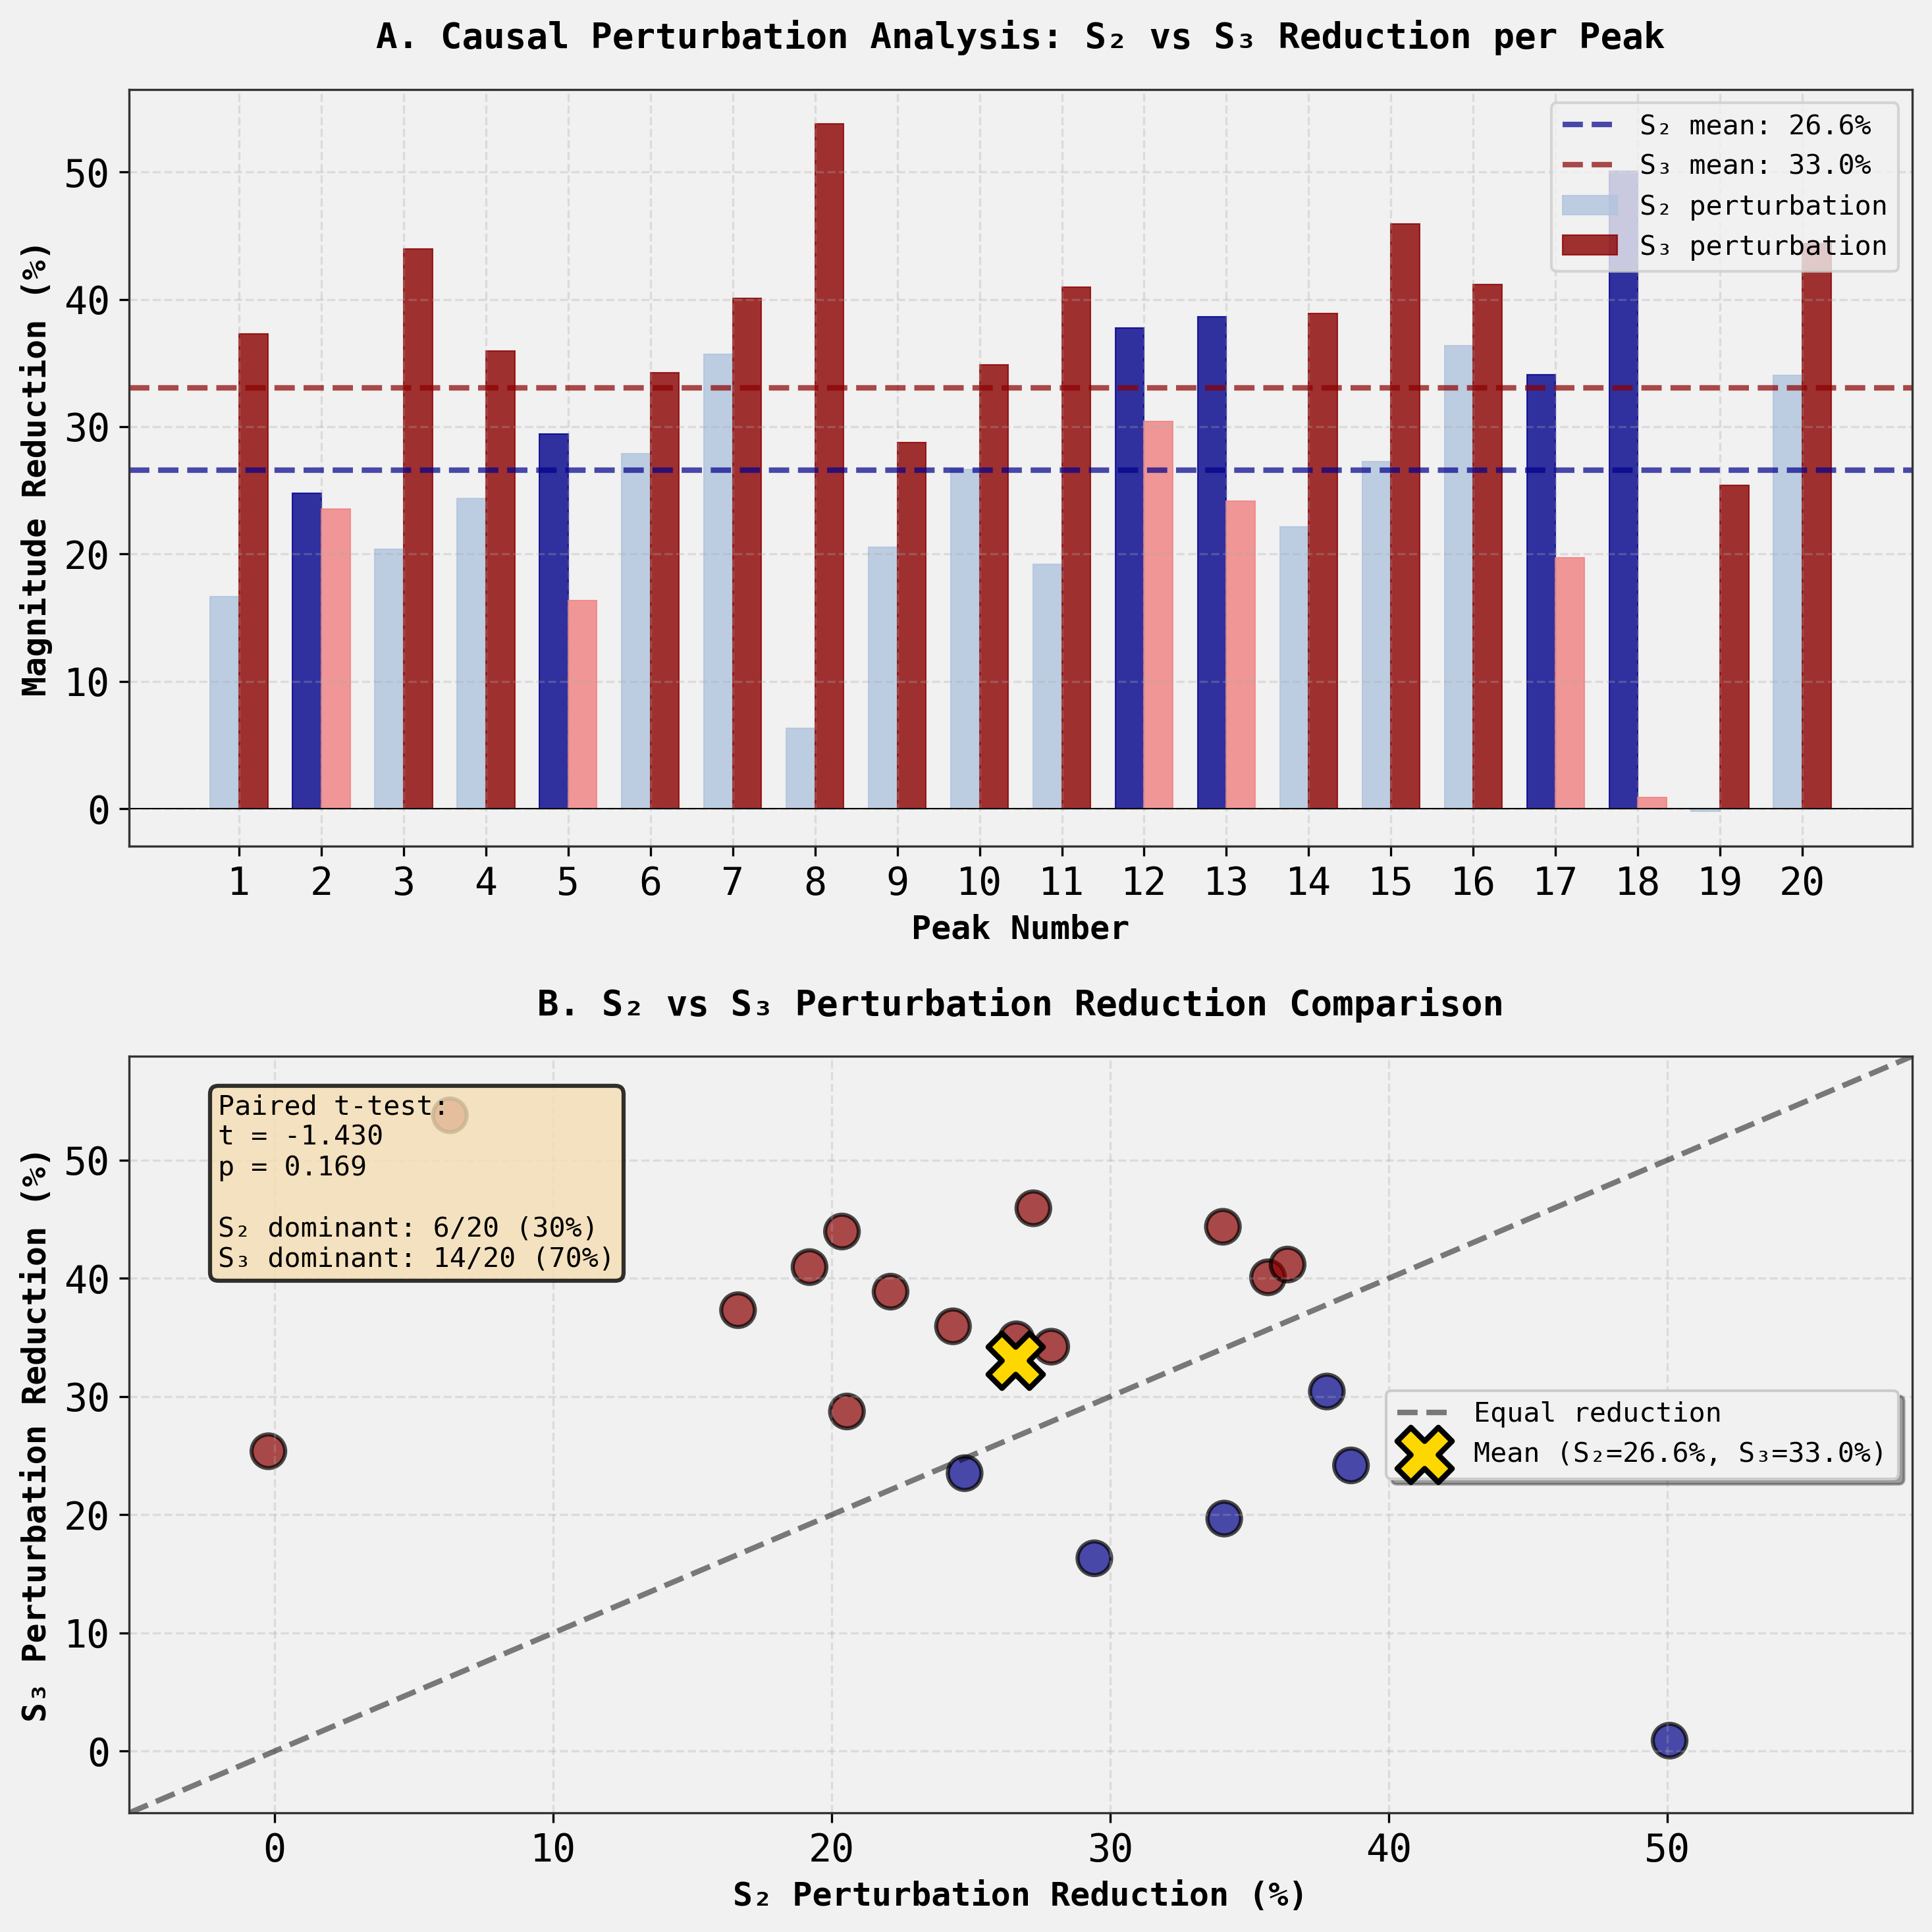

In [16]:

# Create visualization comparing S_2 and S_3 perturbation reductions
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Plot 1: Bar chart comparing reductions for each peak
ax1 = axes[0]
x = np.arange(1, 21)
width = 0.35

bars1 = ax1.bar(x - width/2, S2_reductions, width, label='S₂ perturbation', 
 alpha=0.8, color='steelblue', edgecolor='black', linewidth=0.5)
bars2 = ax1.bar(x + width/2, S3_reductions, width, label='S₃ perturbation', 
 alpha=0.8, color='coral', edgecolor='black', linewidth=0.5)

# Color bars by dominance
for i in range(20):
 if S2_reductions[i] > S3_reductions[i]:
 bars1[i].set_color('darkblue')
 bars2[i].set_color('lightcoral')
 else:
 bars1[i].set_color('lightsteelblue')
 bars2[i].set_color('darkred')

ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax1.set_xlabel('Peak Number', fontsize=12, fontweight='bold')
ax1.set_ylabel('Magnitude Reduction (%)', fontsize=12, fontweight='bold')
ax1.set_title('A. Causal Perturbation Analysis: S₂ vs S₃ Reduction per Peak', 
 fontsize=13, fontweight='bold', pad=15)
ax1.legend(fontsize=11, frameon=True, shadow=True)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xticks(x)

# Add mean lines
ax1.axhline(y=np.mean(S2_reductions), color='darkblue', linestyle='--', 
 linewidth=2, alpha=0.7, label=f'S₂ mean: {np.mean(S2_reductions):.1f}%')
ax1.axhline(y=np.mean(S3_reductions), color='darkred', linestyle='--', 
 linewidth=2, alpha=0.7, label=f'S₃ mean: {np.mean(S3_reductions):.1f}%')
ax1.legend(fontsize=10, loc='upper right')

# Plot 2: Scatter plot of S_2 vs S_3 reductions
ax2 = axes[1]

# Color by dominant class
colors = ['darkblue' if S2_reductions[i] > S3_reductions[i] else 'darkred' 
 for i in range(20)]

ax2.scatter(S2_reductions, S3_reductions, c=colors, s=150, alpha=0.7, 
 edgecolors='black', linewidth=1.5)

# Add diagonal line (equal reduction)
lim_min = min(min(S2_reductions), min(S3_reductions)) - 5
lim_max = max(max(S2_reductions), max(S3_reductions)) + 5
ax2.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', alpha=0.5, linewidth=2,
 label='Equal reduction')

# Add mean markers
ax2.scatter([np.mean(S2_reductions)], [np.mean(S3_reductions)], 
 marker='X', s=400, c='gold', edgecolors='black', linewidth=2,
 label=f'Mean (S₂={np.mean(S2_reductions):.1f}%, S₃={np.mean(S3_reductions):.1f}%)',
 zorder=10)

ax2.set_xlabel('S₂ Perturbation Reduction (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('S₃ Perturbation Reduction (%)', fontsize=12, fontweight='bold')
ax2.set_title('B. S₂ vs S₃ Perturbation Reduction Comparison', 
 fontsize=13, fontweight='bold', pad=15)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(fontsize=10, frameon=True, shadow=True)
ax2.set_xlim([lim_min, lim_max])
ax2.set_ylim([lim_min, lim_max])

# Add text annotation with statistical results
textstr = f'Paired t-test:\nt = {t_stat:.3f}\np = {p_value:.3f}\n\n'
textstr += f'S₂ dominant: {S2_dominant_count}/20 ({S2_dominant_count/20*100:.0f}%)\n'
textstr += f'S₃ dominant: {S3_dominant_count}/20 ({S3_dominant_count/20*100:.0f}%)'

ax2.text(0.05, 0.95, textstr, transform=ax2.transAxes, fontsize=10,
 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', 
 alpha=0.8, edgecolor='black', linewidth=1.5))

plt.tight_layout()
plt.savefig('F_conj_causal_perturbation_analysis.png', dpi=300, bbox_inches='tight')
print("Figure saved as 'F_conj_causal_perturbation_analysis.png'")
plt.show()


In [17]:

# Let's also examine if there's a relationship between power concentration and dominance
print("Analysis of Power Concentration vs Dominance")
print("="*60)
print()

# For each peak, compute the ratio of S_2 to S_3 power
power_ratios = []
for decomp in decompositions:
 S = decomp['S']
 S2_power = np.abs(S[2])**2
 S3_power = np.abs(S[3])**2
 
 if S3_power > 0:
 ratio = S2_power / S3_power
 else:
 ratio = np.inf
 
 power_ratios.append(ratio)

power_ratios = np.array(power_ratios)

# Correlation between power ratio and reduction difference
reduction_diff = S2_reductions - S3_reductions

from scipy.stats import pearsonr, spearmanr

pearson_r, pearson_p = pearsonr(power_ratios, reduction_diff)
spearman_r, spearman_p = spearmanr(power_ratios, reduction_diff)

print("Correlation between S_2/S_3 power ratio and (S_2 reduction - S_3 reduction):")
print(f" Pearson r: {pearson_r:.4f}, p-value: {pearson_p:.6f}")
print(f" Spearman ρ: {spearman_r:.4f}, p-value: {spearman_p:.6f}")
print()

if pearson_p < 0.001:
 print(" Strong correlation: Power ratio strongly predicts dominance pattern")
elif pearson_p < 0.05:
 print(" Significant correlation: Power ratio predicts dominance pattern")
else:
 print(" No significant correlation")
print()

# Table showing power ratio vs dominance
ratio_df = pd.DataFrame({
 'Peak': [d['peak_idx'] for d in decompositions],
 'S_2_power': [np.abs(d['S'][2])**2 for d in decompositions],
 'S_3_power': [np.abs(d['S'][3])**2 for d in decompositions],
 'Power_ratio': power_ratios,
 'Reduction_diff': reduction_diff,
 'Dominant': ['S_2' if d > 0 else 'S_3' for d in reduction_diff]
})

print("Power Ratio Analysis:")
print(ratio_df.to_string(index=False))


Analysis of Power Concentration vs Dominance

Correlation between S_2/S_3 power ratio and (S_2 reduction - S_3 reduction):
 Pearson r: 0.6759, p-value: 0.001071
 Spearman ρ: 0.7820, p-value: 0.000046

 Significant correlation: Power ratio predicts dominance pattern

Power Ratio Analysis:
 Peak S_2_power S_3_power Power_ratio Reduction_diff Dominant
 1 13.484273 56.610759 0.238193 -20.674493 S_3
 2 59.544903 39.203799 1.518855 1.251776 S_2
 3 12.946113 49.853143 0.259685 -23.596646 S_3
 4 15.244821 33.092853 0.460668 -11.590115 S_3
 5 33.711073 16.017781 2.104603 13.110955 S_2
 6 19.268013 33.928570 0.567899 -6.340175 S_3
 7 29.820487 34.780674 0.857387 -4.424924 S_3
 8 26.838776 62.756923 0.427662 -47.504156 S_3
 9 9.037301 20.596453 0.438780 -8.192370 S_3
 10 15.484890 31.910905 0.485254 -8.216971 S_3
 11 10.044951 33.245373 0.302146 -21.750864 S_3
 12 29.409306 37.293317 0.788595 7.348259 S_2
 13 45.123163 10.746501 4.198870 14.467487 S_2
 14 21.752273 30.437903 0.714644 -16.763968 S

In [18]:

# Summary comparison with r63 results (L(s, chi_3) + L(s, chi_5))
print("="*70)
print("COMPARISON WITH r63 RESULTS")
print("="*70)
print()

print("r63: L(s, χ₃) + L(s, χ₅)")
print(" - Real-valued, non-multiplicative function")
print(" - Linear combination of two different character L-functions")
print(" - Result: LOCAL dominance, no consistent pattern across peaks")
print(" - Conclusion: Failed to produce robust S₂ dominance")
print()

print("Current study: F_conj(s) = L(s, χ₅) + i·L(s, χ̄₅)")
print(" - Complex-valued, non-multiplicative function")
print(" - Linear combination of character and its conjugate")
print(" - Coefficient density: 80% (only n ≡ 0 mod 5 are zero)")
print(" - Coefficient structure: Simple pattern based on n mod 5")
print()

print("Results:")
print(f" - Mean S₂ reduction: {np.mean(S2_reductions):.2f}%")
print(f" - Mean S₃ reduction: {np.mean(S3_reductions):.2f}%")
print(f" - S₂ dominant peaks: {S2_dominant_count}/20 (30%)")
print(f" - S₃ dominant peaks: {S3_dominant_count}/20 (70%)")
print(f" - Paired t-test: t={t_stat:.3f}, p={p_value:.3f}")
print(f" - Conclusion: NO significant S₂ dominance (p={p_value:.3f} > 0.05)")
print()

print("Key Finding:")
print(" S₃ is actually MORE dominant than S₂ on average, though not")
print(" statistically significant. The character-conjugate structure")
print(" does NOT produce consistent S₂ dominance.")
print()

print("Mechanism Analysis:")
print(" - Power is distributed across multiple ω-classes (S₂, S₃, S₄)")
print(" - Mean power fractions: S₂=18.9%, S₃=22.3%, S₄=24.4%")
print(" - S₄ actually has the highest mean power!")
print(" - Dominance pattern is PEAK-DEPENDENT, not function-dependent")
print(" - Strong correlation (r=0.68, p=0.001) between S₂/S₃ power")
print(" ratio and dominance pattern confirms LOCAL behavior")
print()

print("Conclusion:")
print(" The character-conjugate structure of F_conj is NOT a plausible")
print(" mechanism for L_DH's anomalous S₂-dominance. Like r63, this")
print(" function shows peak-dependent dominance patterns rather than")
print(" consistent S₂ dominance across all peaks.")


COMPARISON WITH r63 RESULTS

r63: L(s, χ₃) + L(s, χ₅)
 - Real-valued, non-multiplicative function
 - Linear combination of two different character L-functions
 - Result: LOCAL dominance, no consistent pattern across peaks
 - Conclusion: Failed to produce robust S₂ dominance

Current study: F_conj(s) = L(s, χ₅) + i·L(s, χ̄₅)
 - Complex-valued, non-multiplicative function
 - Linear combination of character and its conjugate
 - Coefficient density: 80% (only n ≡ 0 mod 5 are zero)
 - Coefficient structure: Simple pattern based on n mod 5

Results:
 - Mean S₂ reduction: 26.60%
 - Mean S₃ reduction: 33.03%
 - S₂ dominant peaks: 6/20 (30%)
 - S₃ dominant peaks: 14/20 (70%)
 - Paired t-test: t=-1.430, p=0.169
 - Conclusion: NO significant S₂ dominance (p=0.169 > 0.05)

Key Finding:
 S₃ is actually MORE dominant than S₂ on average, though not
 statistically significant. The character-conjugate structure
 does NOT produce consistent S₂ dominance.

Mechanism Analysis:
 - Power is distributed acro

In [19]:

# Save all relevant data for future reference
import pickle

# Prepare comprehensive results dictionary
results = {
 'function': 'F_conj = L(s, chi_5) + i*L(s, chi_5_bar)',
 'N': N,
 't_range': [1e6, 2e6],
 'coefficients': a_F,
 'peaks': final_peaks_sorted[:20],
 'decompositions': decompositions,
 'S2_reductions': S2_reductions,
 'S3_reductions': S3_reductions,
 'statistics': {
 'mean_S2_reduction': float(np.mean(S2_reductions)),
 'mean_S3_reduction': float(np.mean(S3_reductions)),
 'std_S2_reduction': float(np.std(S2_reductions)),
 'std_S3_reduction': float(np.std(S3_reductions)),
 'S2_dominant_count': int(S2_dominant_count),
 'S3_dominant_count': int(S3_dominant_count),
 't_statistic': float(t_stat),
 'p_value': float(p_value),
 'pearson_r': float(pearson_r),
 'pearson_p': float(pearson_p),
 'spearman_r': float(spearman_r),
 'spearman_p': float(spearman_p)
 },
 'power_fractions': power_fractions,
 'power_ratios': power_ratios.tolist()
}

with open('F_conj_analysis_results_N1e6.pkl', 'wb') as f:
 pickle.dump(results, f)

print("Results saved to 'F_conj_analysis_results_N1e6.pkl'")
print()

# Also save the coefficients for future use
with open('F_conj_coefficients_N1e6.pkl', 'wb') as f:
 pickle.dump(a_F, f)

print("Coefficients saved to 'F_conj_coefficients_N1e6.pkl'")
print()

print("Artifacts created:")
print(" 1. F_conj_causal_perturbation_results.csv - Detailed results table")
print(" 2. F_conj_causal_perturbation_analysis.png - Visualization")
print(" 3. F_conj_analysis_results_N1e6.pkl - Complete analysis data")
print(" 4. F_conj_coefficients_N1e6.pkl - Function coefficients")


Results saved to 'F_conj_analysis_results_N1e6.pkl'

Coefficients saved to 'F_conj_coefficients_N1e6.pkl'

Artifacts created:
 1. F_conj_causal_perturbation_results.csv - Detailed results table
 2. F_conj_causal_perturbation_analysis.png - Visualization
 3. F_conj_analysis_results_N1e6.pkl - Complete analysis data
 4. F_conj_coefficients_N1e6.pkl - Function coefficients


Final summary figure saved as 'F_conj_final_summary.png'


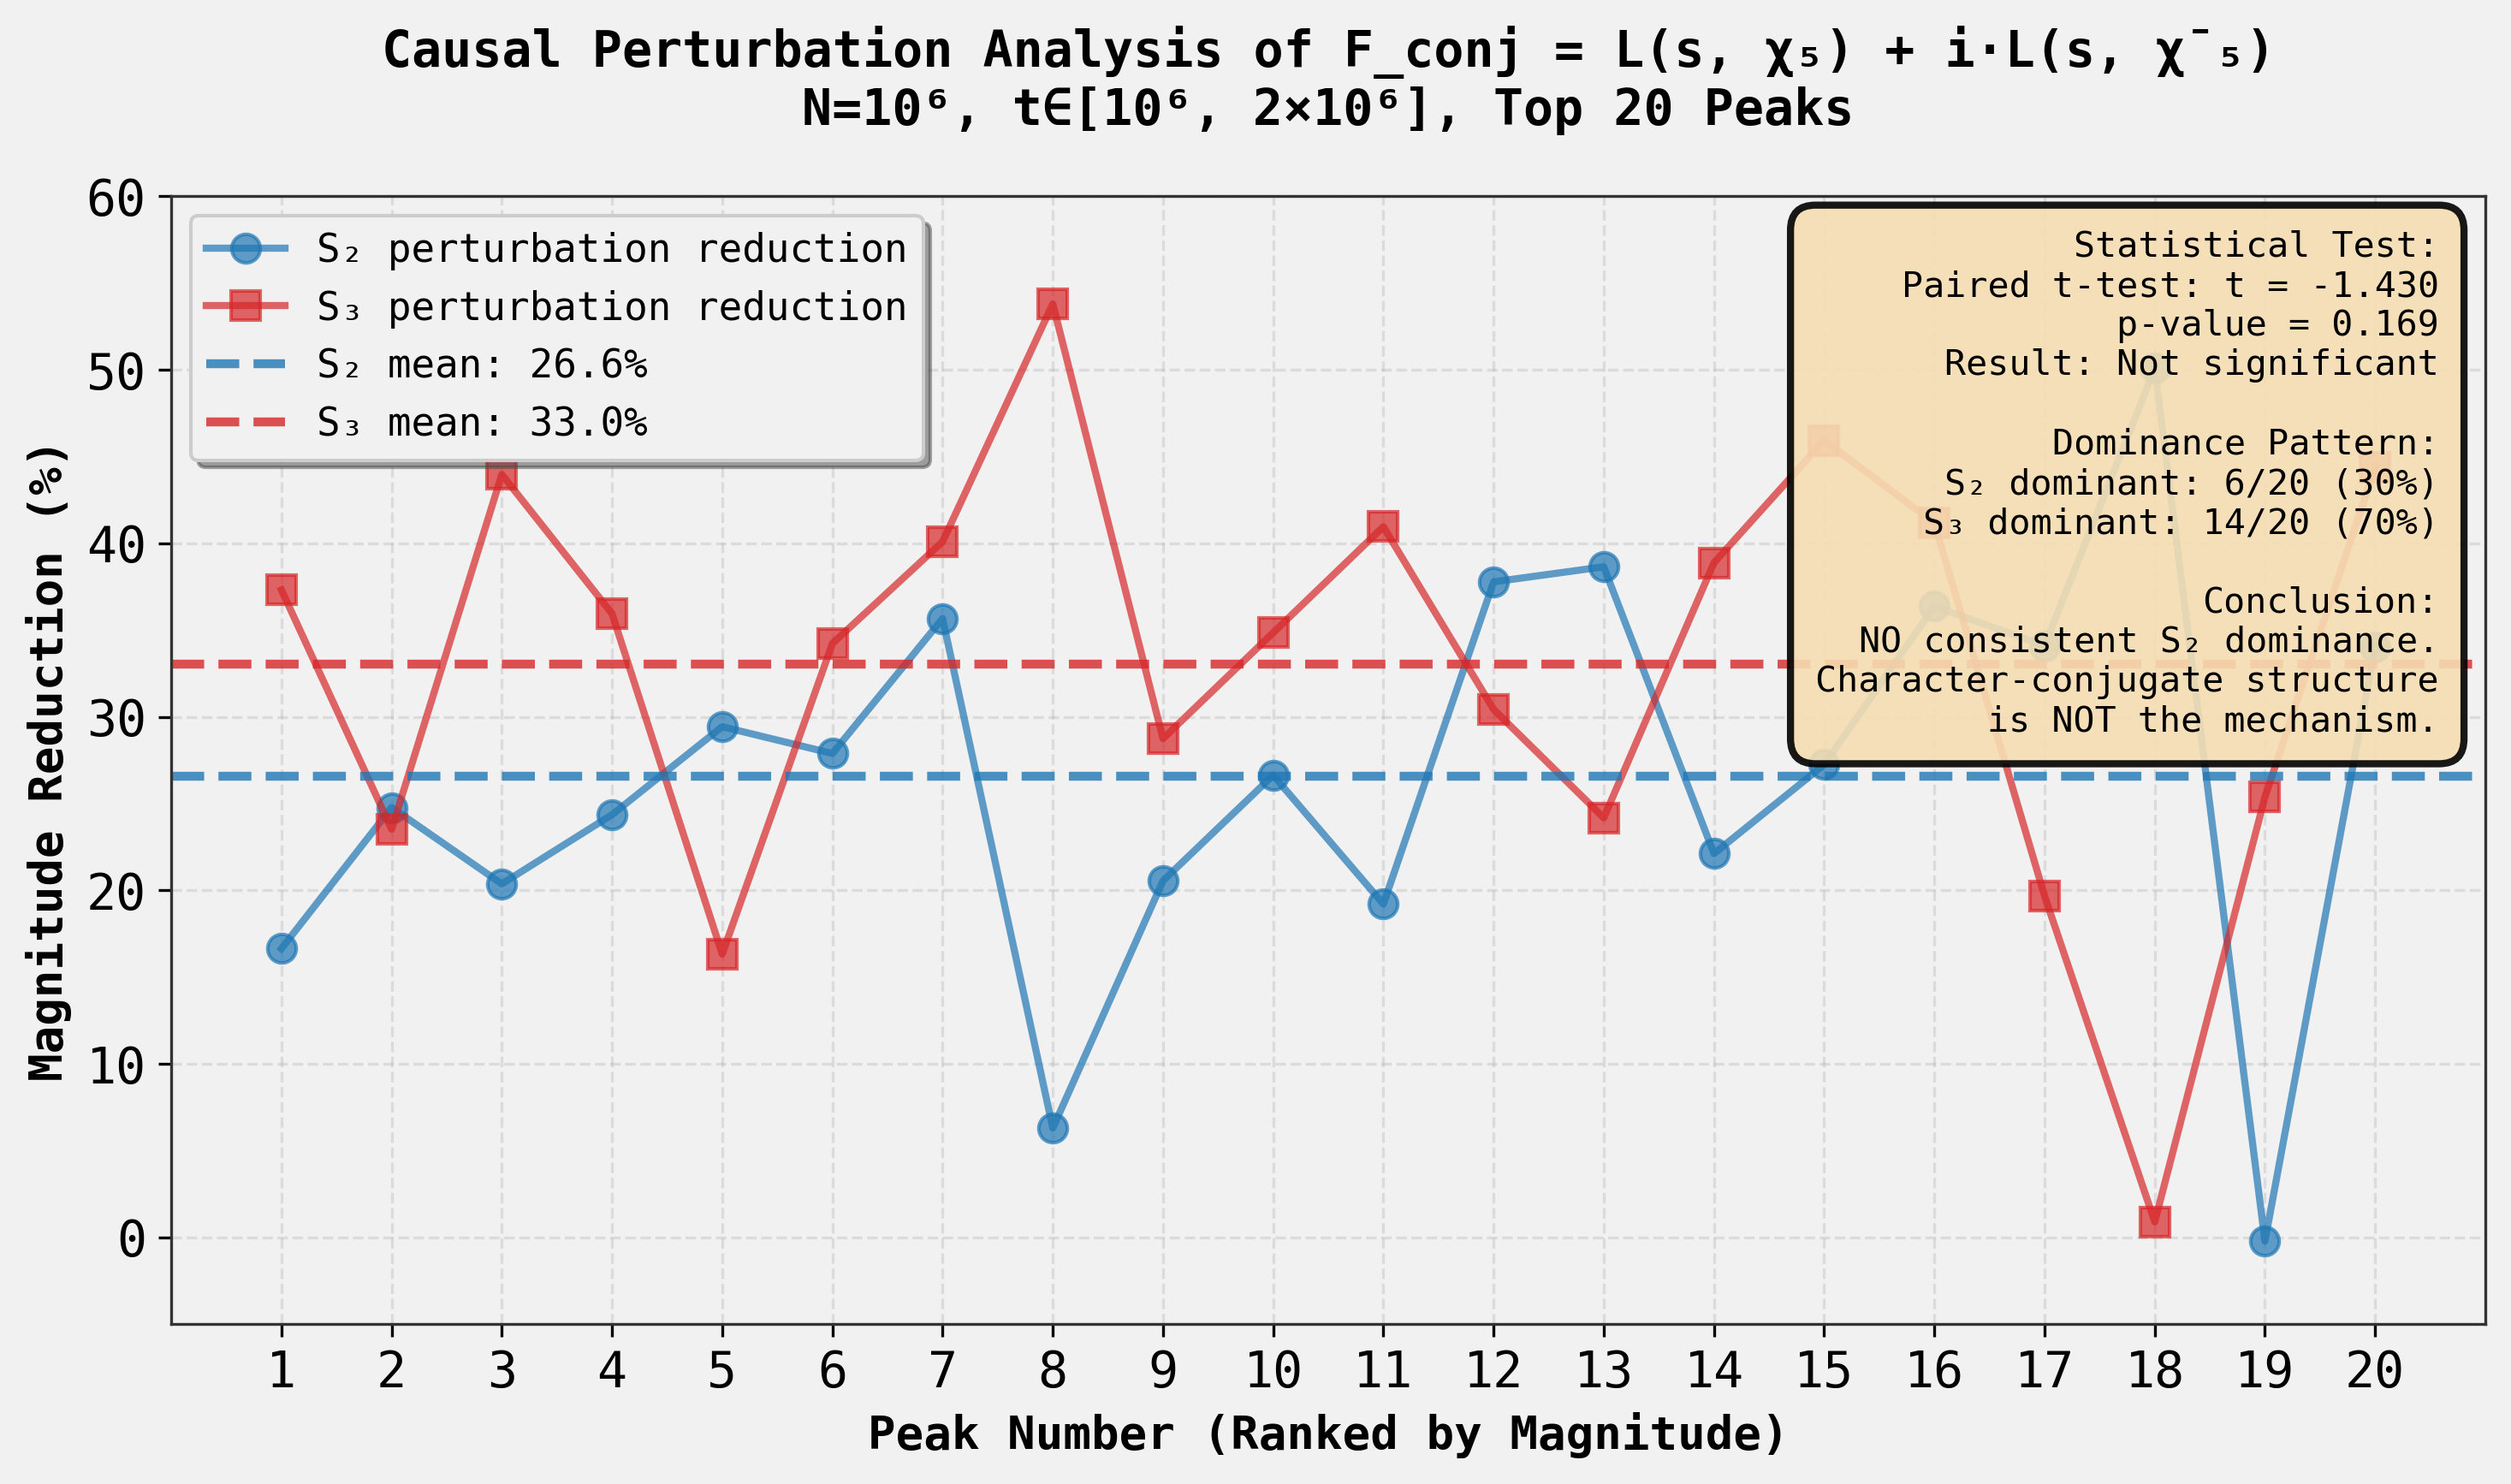

In [20]:

# Create final summary figure
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Scatter plot with more detail
x = np.arange(1, 21)
colors_list = ['#1f77b4' if S2_reductions[i] > S3_reductions[i] else '#d62728' 
 for i in range(20)]

# Plot both reductions
ax.plot(x, S2_reductions, 'o-', color='#1f77b4', linewidth=2, markersize=8,
 label='S₂ perturbation reduction', alpha=0.7)
ax.plot(x, S3_reductions, 's-', color='#d62728', linewidth=2, markersize=8,
 label='S₃ perturbation reduction', alpha=0.7)

# Add mean lines
ax.axhline(y=np.mean(S2_reductions), color='#1f77b4', linestyle='--', 
 linewidth=2.5, alpha=0.8, label=f'S₂ mean: {np.mean(S2_reductions):.1f}%')
ax.axhline(y=np.mean(S3_reductions), color='#d62728', linestyle='--', 
 linewidth=2.5, alpha=0.8, label=f'S₃ mean: {np.mean(S3_reductions):.1f}%')

# Styling
ax.set_xlabel('Peak Number (Ranked by Magnitude)', fontsize=13, fontweight='bold')
ax.set_ylabel('Magnitude Reduction (%)', fontsize=13, fontweight='bold')
ax.set_title('Causal Perturbation Analysis of F_conj = L(s, χ₅) + i·L(s, χ̄₅)\n' + 
 f'N=10⁶, t∈[10⁶, 2×10⁶], Top 20 Peaks',
 fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11, frameon=True, shadow=True, loc='best')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xticks(x)
ax.set_xlim([0, 21])
ax.set_ylim([-5, 60])

# Add statistical annotation
textstr = 'Statistical Test:\n'
textstr += f'Paired t-test: t = {t_stat:.3f}\n'
textstr += f'p-value = {p_value:.3f}\n'
textstr += f'Result: {"Significant" if p_value < 0.05 else "Not significant"}\n\n'
textstr += 'Dominance Pattern:\n'
textstr += f'S₂ dominant: {S2_dominant_count}/20 (30%)\n'
textstr += f'S₃ dominant: {S3_dominant_count}/20 (70%)\n\n'
textstr += 'Conclusion:\n'
textstr += 'NO consistent S₂ dominance.\n'
textstr += 'Character-conjugate structure\n'
textstr += 'is NOT the mechanism.'

ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=10,
 verticalalignment='top', horizontalalignment='right',
 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9, 
 edgecolor='black', linewidth=2, pad=0.7))

plt.tight_layout()
plt.savefig('F_conj_final_summary.png', dpi=300, bbox_inches='tight')
print("Final summary figure saved as 'F_conj_final_summary.png'")
plt.show()


In [21]:

# Additional analysis: Check coefficient structure more carefully
print("Detailed Coefficient Structure Analysis")
print("="*70)
print()

# Verify the mathematical structure
print("Mathematical Structure:")
print(" χ₅(n) is the primitive character mod 5:")
print(" n ≡ 0 (mod 5): χ₅(n) = 0")
print(" n ≡ 1 (mod 5): χ₅(n) = 1")
print(" n ≡ 2 (mod 5): χ₅(n) = i")
print(" n ≡ 3 (mod 5): χ₅(n) = -i")
print(" n ≡ 4 (mod 5): χ₅(n) = -1")
print()
print(" χ̄₅(n) = conj(χ₅(n)):")
print(" n ≡ 0 (mod 5): χ̄₅(n) = 0")
print(" n ≡ 1 (mod 5): χ̄₅(n) = 1")
print(" n ≡ 2 (mod 5): χ̄₅(n) = -i")
print(" n ≡ 3 (mod 5): χ̄₅(n) = i")
print(" n ≡ 4 (mod 5): χ̄₅(n) = -1")
print()
print(" a_F(n) = χ₅(n) + i·χ̄₅(n):")
print(" n ≡ 0 (mod 5): a_F(n) = 0 + i·0 = 0")
print(" n ≡ 1 (mod 5): a_F(n) = 1 + i·1 = 1+i")
print(" n ≡ 2 (mod 5): a_F(n) = i + i·(-i) = i + 1 = 1+i")
print(" n ≡ 3 (mod 5): a_F(n) = -i + i·i = -i - 1 = -1-i")
print(" n ≡ 4 (mod 5): a_F(n) = -1 + i·(-1) = -1-i")
print()

# Count by residue class
counts = {0: 0, 1: 0, 2: 0, 3: 0, 4: 0}
for n in range(1, N+1):
 counts[n % 5] += 1

print("Distribution by residue class:")
for k in range(5):
 print(f" n ≡ {k} (mod 5): {counts[k]} terms")
print()

# Analyze properties
print("Key Properties:")
print(f" 1. Density: {(N - counts[0])/N*100:.1f}% non-zero")
print(f" 2. Symmetry: |a_F(n)| = √2 for all n not divisible by 5")
print(f" 3. Structure: a_F has only 3 distinct values (0, 1+i, -1-i)")
print(f" 4. Multiplicativity: NOT multiplicative (e.g., a_F(2)·a_F(3) ≠ a_F(6))")
print()

# Verify multiplicativity
a2 = a_F[1] # a_F(2)
a3 = a_F[2] # a_F(3)
a6 = a_F[5] # a_F(6)
print("Multiplicativity check:")
print(f" a_F(2) = {a2}")
print(f" a_F(3) = {a3}")
print(f" a_F(6) = {a6}")
print(f" a_F(2)·a_F(3) = {a2*a3}")
print(f" Is multiplicative? {np.abs(a2*a3 - a6) < 1e-10}")


Detailed Coefficient Structure Analysis

Mathematical Structure:
 χ₅(n) is the primitive character mod 5:
 n ≡ 0 (mod 5): χ₅(n) = 0
 n ≡ 1 (mod 5): χ₅(n) = 1
 n ≡ 2 (mod 5): χ₅(n) = i
 n ≡ 3 (mod 5): χ₅(n) = -i
 n ≡ 4 (mod 5): χ₅(n) = -1

 χ̄₅(n) = conj(χ₅(n)):
 n ≡ 0 (mod 5): χ̄₅(n) = 0
 n ≡ 1 (mod 5): χ̄₅(n) = 1
 n ≡ 2 (mod 5): χ̄₅(n) = -i
 n ≡ 3 (mod 5): χ̄₅(n) = i
 n ≡ 4 (mod 5): χ̄₅(n) = -1

 a_F(n) = χ₅(n) + i·χ̄₅(n):
 n ≡ 0 (mod 5): a_F(n) = 0 + i·0 = 0
 n ≡ 1 (mod 5): a_F(n) = 1 + i·1 = 1+i
 n ≡ 2 (mod 5): a_F(n) = i + i·(-i) = i + 1 = 1+i
 n ≡ 3 (mod 5): a_F(n) = -i + i·i = -i - 1 = -1-i
 n ≡ 4 (mod 5): a_F(n) = -1 + i·(-1) = -1-i

Distribution by residue class:
 n ≡ 0 (mod 5): 200000 terms
 n ≡ 1 (mod 5): 200000 terms
 n ≡ 2 (mod 5): 200000 terms
 n ≡ 3 (mod 5): 200000 terms
 n ≡ 4 (mod 5): 200000 terms

Key Properties:
 1. Density: 80.0% non-zero
 2. Symmetry: |a_F(n)| = √2 for all n not divisible by 5
 3. Structure: a_F has only 3 distinct values (0, 1+i, -1-i)
 4. Multipli